In [37]:
import sys
from pathlib import Path

PROJECT_ROOT = str(Path.cwd().parent)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import add_borough_dummies

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

sns.set_style("whitegrid")

In [39]:
DATA_PATH = "../data/raw/rental_report_final.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (260, 25)


,nta2020,ntaname,num_bbls,avg_unitsres,avg_unitstotal,avg_yearbuilt,avg_market_value,num_properties,school_count,avg_ats,murder,rape,robbery,felony_assault,burglary,grand_larceny,grand_larceny_auto,total_violations,buildings_with_violations,violations_per_building,rent_impairing_violations,pct_rent_impairing,rent_num_properties,avg_monthly_rent,median_monthly_rent
0,QN8191,Flushing Meadows-Corona Park,31,0.000000,0.129032,442.806452,5.577701e+03,36.487311,NaN,NaN,0.595083,17.759920,185.886253,263.831372,92.675146,383.097319,118.814453,14.0,1.0,14.0000,0.0,0.0000,NaN,NaN,NaN
1,QN0601,Rego Park,2583,5.470770,5.953930,1906.347658,7.774261e+05,4704.243264,NaN,NaN,0.225370,3.490564,20.929933,34.290739,32.218593,89.470923,34.229803,10802.0,323.0,33.4427,610.0,0.0565,28.0,1902.657064,1869.060588
2,BK1204,Mapleton-Midwood (West),5143,2.547540,2.723702,1904.803228,8.090730e+05,6279.703180,NaN,NaN,0.976761,4.217520,32.988229,64.446533,41.426248,147.547358,66.761663,26663.0,933.0,28.5777,1366.0,0.0512,13.0,3324.565056,2444.750000
3,BX0702,Bedford Park,1309,17.839572,18.310924,1835.779985,1.097847e+06,1385.907912,NaN,NaN,2.108588,11.711685,117.391944,206.040030,55.494601,238.921371,89.940230,143154.0,847.0,169.0130,9345.0,0.0653,6.0,1946.530777,1529.090556
4,BK1771,Holy Cross Cemetery,1,0.000000,0.000000,1917.000000,8.039164e+01,1.038566,NaN,NaN,0.364676,2.051302,11.259369,36.649930,7.794948,27.760955,8.205208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
df.info()
# Unique key check
print("Unique NTAs:", df["nta2020"].nunique())
print("Total rows:", len(df))


<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   nta2020                    260 non-null    str    
 1   ntaname                    260 non-null    str    
 2   num_bbls                   260 non-null    int64  
 3   avg_unitsres               260 non-null    float64
 4   avg_unitstotal             260 non-null    float64
 5   avg_yearbuilt              260 non-null    float64
 6   avg_market_value           259 non-null    float64
 7   num_properties             259 non-null    float64
 8   school_count               0 non-null      float64
 9   avg_ats                    0 non-null      float64
 10  murder                     260 non-null    float64
 11  rape                       260 non-null    float64
 12  robbery                    260 non-null    float64
 13  felony_assault             260 non-null    float64
 14  burgl

In [41]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing.head(20)

school_count                 260
avg_ats                      260
median_monthly_rent           85
avg_monthly_rent              85
rent_num_properties           85
pct_rent_impairing            59
rent_impairing_violations     59
violations_per_building       59
buildings_with_violations     59
total_violations              59
avg_market_value               1
num_properties                 1
grand_larceny                  0
grand_larceny_auto             0
nta2020                        0
burglary                       0
felony_assault                 0
ntaname                        0
rape                           0
murder                         0
dtype: int64

school_count and avg_ats returned entirely null after the NTA-level join — excluded from modeling, documented in README

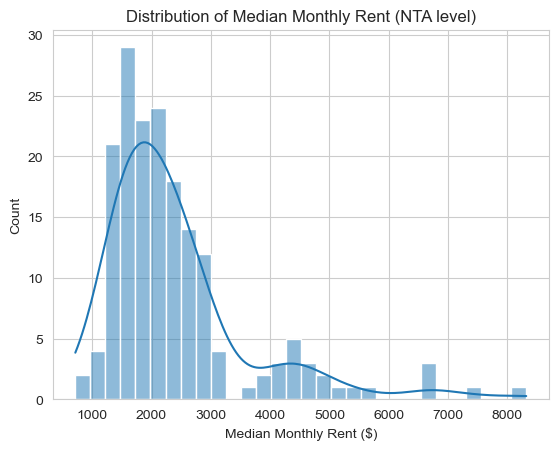

In [42]:
sns.histplot(df["median_monthly_rent"], bins=30, kde=True)
plt.title("Distribution of Median Monthly Rent (NTA level)")
plt.xlabel("Median Monthly Rent ($)")
plt.show()

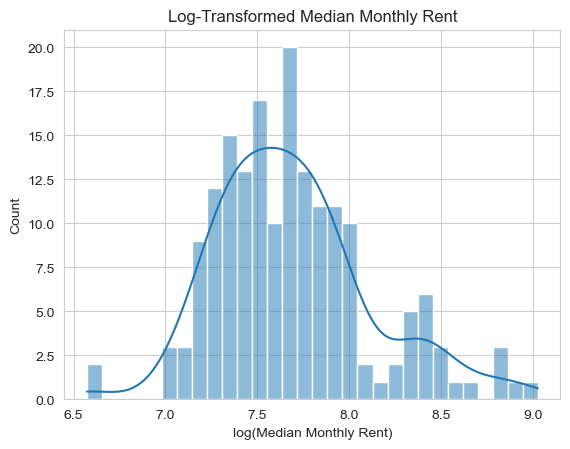

In [43]:
df["log_median_rent"] = np.log(df["median_monthly_rent"])

sns.histplot(df["log_median_rent"], bins=30, kde=True)
plt.title("Log-Transformed Median Monthly Rent")
plt.xlabel("log(Median Monthly Rent)")
plt.show()


In [44]:
df_labeled = df[df["median_monthly_rent"].notna()].copy()
df_unlabeled = df[df["median_monthly_rent"].isna()].copy()

print("Labeled NTAs:", df_labeled.shape[0])
print("Unlabeled NTAs:", df_unlabeled.shape[0])
df_labeled.describe().T


Labeled NTAs: 175
Unlabeled NTAs: 85


,count,mean,std,min,25%,50%,75%,max
num_bbls,175.0,4.098360e+03,3.070163e+03,242.000000,1606.500000,3424.000000,5.773500e+03,1.636100e+04
avg_unitsres,175.0,9.744576e+00,1.122654e+01,1.180411,2.742036,4.952069,1.369730e+01,6.569835e+01
avg_unitstotal,175.0,1.092270e+01,1.273025e+01,1.309333,2.958494,5.405376,1.460155e+01,7.467679e+01
avg_yearbuilt,175.0,1.833949e+03,7.463217e+01,1409.140496,1797.766915,1846.896025,1.889488e+03,1.933900e+03
avg_market_value,175.0,2.611493e+07,1.942215e+08,26271.857177,621720.407677,934439.686844,1.748425e+06,2.281293e+09
num_properties,175.0,5.769985e+03,3.424651e+03,220.234223,3392.878739,5356.789284,7.851628e+03,1.647762e+04
school_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_ats,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
murder,175.0,1.612832e+00,1.795411e+00,0.000000,0.482423,0.963773,2.113112e+00,1.023932e+01
rape,175.0,8.824489e+00,6.299496e+00,1.074336,4.212606,7.537787,1.205824e+01,3.985359e+01


In [45]:
df_labeled.to_csv("../data/processed/train.csv", index=False)
df_unlabeled.to_csv("../data/processed/unlabeled.csv", index=False)
